# GAN Evaluation
Evaluates a trained generator: visual samples, grad norms, D/G outputs.

## Imports

In [10]:
import torch
import torch.nn  as nn
from torchvision.utils import make_grid
from utils import Config, load_checkpoint, set_seed
from models import get_generator, get_discriminator
from losses import get_loss
from dataset import get_dataloader
from transforms import get_transform

import numpy as np
from tqdm import tqdm
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
from pathlib import Path
import yaml

import warnings
warnings.filterwarnings('ignore')


## Config

In [11]:
config_path = Path("configs/test_classic_baseline_1.yaml")
checkpoint_path = Path("checkpoints/classic_baseline_1_checkpoint.pt")

In [12]:
with open(config_path, "r") as f:
    config_dict = yaml.safe_load(f)
config = Config.from_dict(config_dict)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
set_seed(config.seed)

config.n_workers = 0
config.persistent_workers = False
config.prefetch_factor = None

## Get data & Load checkpoints

In [13]:
transforms = get_transform(config.input_dim)
dataloader = get_dataloader(config, transforms)
G = get_generator(config).to(device)
D = get_discriminator(config).to(device)
criterion = get_loss(config)

Dataloader initialized with: num_workers=0, batch_size=16.
Generator: baseline_G
Discriminator: D
Loss function: BCE


In [14]:
G, D, state_dict = load_checkpoint(
    path=checkpoint_path, 
    G=G, D=D,
    map_location=device,
)
curr_epoch = state_dict["epoch"] + 1
D_losses = state_dict["D_losses"]
G_losses = state_dict["G_losses"]
print(f"Resumed '{checkpoint_path}' at epoch {curr_epoch}.")

Resumed 'checkpoints\classic_baseline_1_checkpoint.pt' at epoch 50.


## Samples visualization

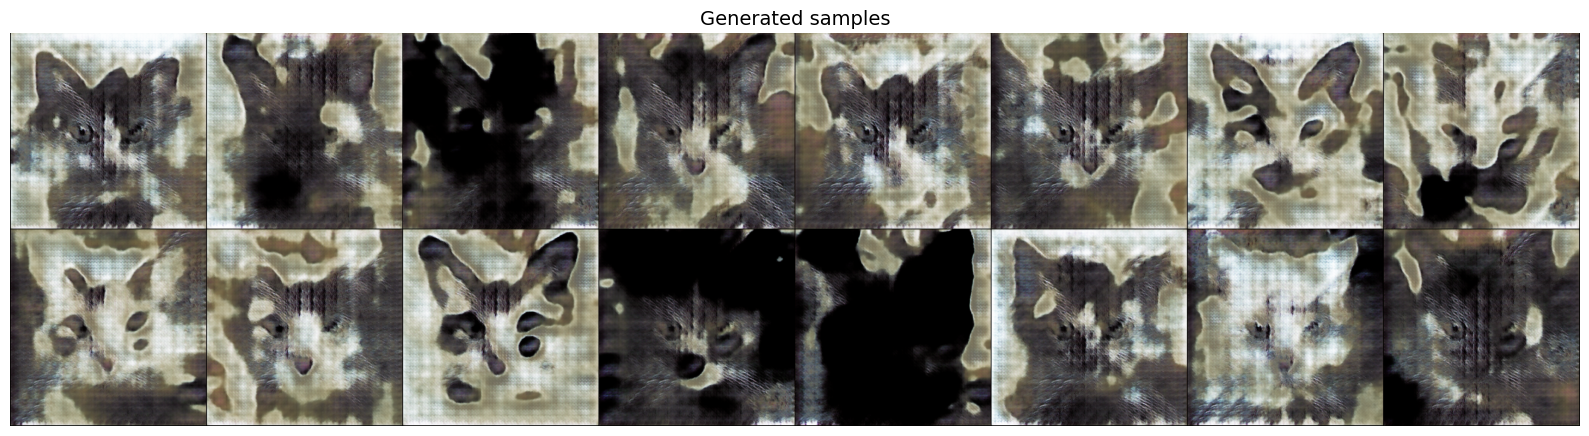

In [6]:
def show_samples(G, n=64, nrow=8, title='Generated samples'):
    with torch.no_grad():
        z = torch.randn(n, config.noise_dim, device=device)
        imgs = G(z).cpu().clamp(-1, 1)
        imgs = (imgs + 1) / 2          # [-1,1] → [0,1]

    grid = make_grid(imgs, nrow=nrow, padding=2)
    fig, ax = plt.subplots(figsize=(16, 16))
    ax.imshow(grid.permute(1, 2, 0))
    ax.axis('off')
    ax.set_title(title, fontsize=14)
    plt.tight_layout()
    plt.show()
    return imgs

imgs = show_samples(G, n=16)

## D output distribution

100%|██████████| 354/354 [01:24<00:00,  4.19it/s]


D(real): mean=0.997 std=0.041
D(fake): mean=0.043 std=0.113
Balance (real-fake): 0.954 (0.3-0.5 is ok)


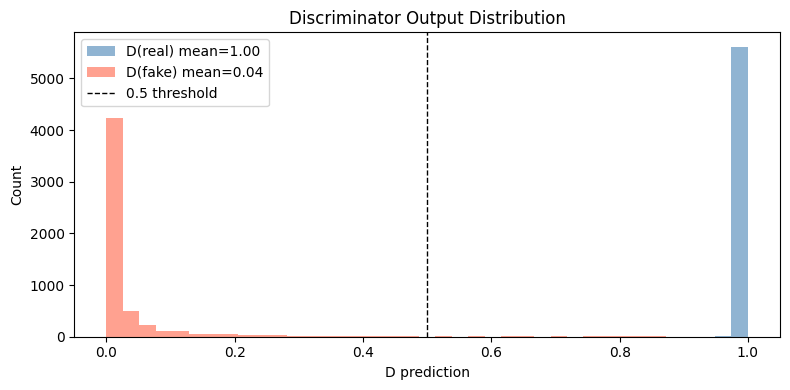

In [16]:
d_real_scores, d_fake_scores = [], []

with torch.no_grad():
    for real_imgs in tqdm(dataloader):
        real_imgs = real_imgs.to(device)
        z = torch.randn(len(real_imgs), config.noise_dim, device=device)
        fake_imgs = G(z)

        d_real = torch.sigmoid(D(real_imgs)).cpu().squeeze()
        d_fake = torch.sigmoid(D(fake_imgs)).cpu().squeeze()

        d_real_scores.append(d_real)
        d_fake_scores.append(d_fake)

d_real_scores = torch.cat(d_real_scores).numpy()
d_fake_scores = torch.cat(d_fake_scores).numpy()

print(f'D(real): mean={d_real_scores.mean():.3f} std={d_real_scores.std():.3f}')
print(f'D(fake): mean={d_fake_scores.mean():.3f} std={d_fake_scores.std():.3f}')
print(f'Balance (real-fake): {d_real_scores.mean() - d_fake_scores.mean():.3f} (0.3-0.5 is ok)')

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 40)
ax.hist(d_real_scores, bins=bins, alpha=0.6, label=f'D(real) mean={d_real_scores.mean():.2f}', color='steelblue')
ax.hist(d_fake_scores, bins=bins, alpha=0.6, label=f'D(fake) mean={d_fake_scores.mean():.2f}', color='tomato')
ax.axvline(0.5, color='k', linestyle='--', linewidth=1, label='0.5 threshold')
ax.set_xlabel('D prediction')
ax.set_ylabel('Count')
ax.set_title('Discriminator Output Distribution')
ax.legend()

plt.tight_layout()
plt.show()

## Grad Norm Analysis

G grad norm: mean=15.941 max=19.350clip_rate=100.0% (max_norm=3)
D grad norm: mean=8.995 max=26.248clip_rate=56.0% (max_norm=5)


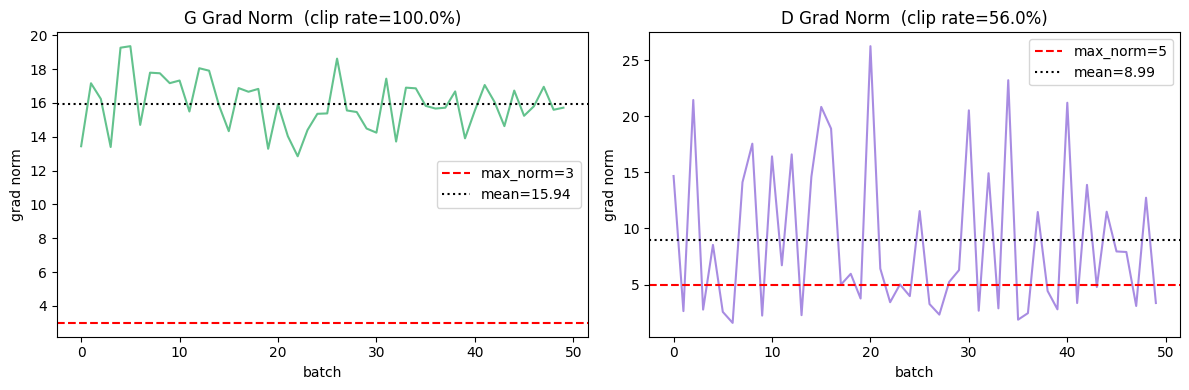

In [ ]:
N_BATCHES = 50

def compute_grad_norm(model: nn.Module):
    total = 0.0
    for p in model.parameters():
        if p.grad is not None:
            total += p.grad.norm(2).item() ** 2
    return total ** 0.5

G_norms, D_norms = [], []
G_clipped, D_clipped = 0, 0

G.train()
D.train()
loader_iter = iter(dataloader)

for _ in range(N_BATCHES):
    try:
        real_imgs = next(loader_iter)
    except StopIteration:
        loader_iter = iter(dataloader)
        real_imgs  = next(loader_iter)

    real_imgs = real_imgs.to(device)
    bs = len(real_imgs)

    # D grad norm
    D.zero_grad()
    z = torch.randn(bs, config.noise_dim, device=device)
    with torch.no_grad():
        fake = G(z)
    d_loss = criterion.D_loss(D(real_imgs), D(fake))
    d_loss.backward()
    d_norm = compute_grad_norm(D)
    D_norms.append(d_norm)
    if d_norm > config.D_max_norm:
        D_clipped += 1

    # G grad norm
    G.zero_grad()
    z = torch.randn(bs, config.noise_dim, device=device)
    g_loss = criterion.G_loss(D(G(z)))
    g_loss.backward()
    g_norm = compute_grad_norm(G)
    G_norms.append(g_norm)
    if g_norm > config.G_max_norm:
        G_clipped += 1

G.eval()
D.eval()

# summary
print(f'G grad norm: mean={np.mean(G_norms):.3f} max={np.max(G_norms):.3f}'
      f'clip_rate={G_clipped/N_BATCHES:.1%} (max_norm={config.G_max_norm})')
print(f'D grad norm: mean={np.mean(D_norms):.3f} max={np.max(D_norms):.3f}'
      f'clip_rate={D_clipped/N_BATCHES:.1%} (max_norm={config.D_max_norm})')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, norms, name, max_norm, color in zip(
        axes,
        [G_norms, D_norms],
        ['G', 'D'],
        [config.G_max_norm, config.D_max_norm],
        ['mediumseagreen', 'mediumpurple']):
    ax.plot(norms, color=color, alpha=0.8)
    ax.axhline(max_norm, color='red', linestyle='--', label=f'max_norm={max_norm}')
    ax.axhline(np.mean(norms), color='k', linestyle=':', label=f'mean={np.mean(norms):.2f}')
    ax.set_title(f'{name} Grad Norm  (clip rate={sum(n>max_norm for n in norms)/len(norms):.1%})')
    ax.set_xlabel('batch')
    ax.set_ylabel('grad norm')
    ax.legend()

plt.tight_layout()
plt.show()

## Mode Collapse Check

Pairwise cosine similarity: mean=0.161 (mean > 0.85 - mode collapse)


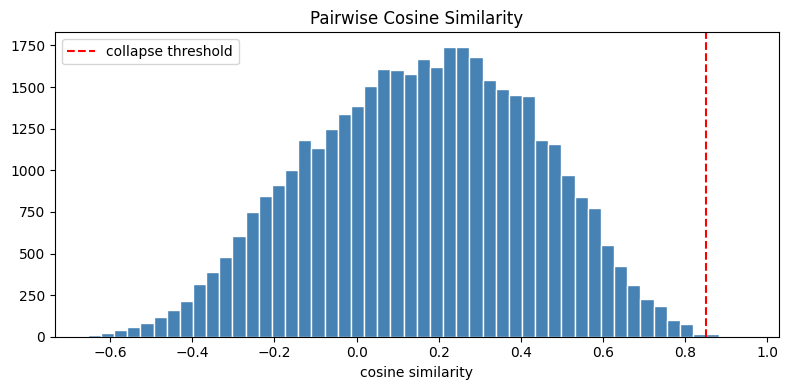

In [17]:
with torch.no_grad():
    z = torch.randn(config.input_dim, config.noise_dim, device=device)
    fake = G(z).view(config.input_dim, -1).cpu()

# cos similarity
idx = torch.randperm(config.input_dim)[:200]
feat = fake[idx]
feat = feat / feat.norm(dim=1, keepdim=True)
sim_matrix = (feat @ feat.T).numpy()
# exclude diagonal
mask = ~np.eye(len(feat), dtype=bool)
pairwise_sim = sim_matrix[mask]
print(f'Pairwise cosine similarity: mean={pairwise_sim.mean():.3f} (mean > 0.85 - mode collapse)')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pairwise_sim, bins=50, color='steelblue', edgecolor='white')
ax.axvline(0.85, color='red', linestyle='--', label='collapse threshold')
ax.set_title('Pairwise Cosine Similarity')
ax.set_xlabel('cosine similarity')
ax.legend()

plt.tight_layout()
plt.show()